In [1]:
import wandb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Get run(s)

In [2]:
def get_run_paths(entity: str, project: str, run_names: list[str]) -> dict[str, str]:
    """
    Given an entity, project, and a list of run names, return a dict
    mapping each found run name -> run path (entity/project/run_id).

    Args:
        entity (str): W&B entity (user or team)
        project (str): W&B project name
        run_names (list[str]): list of run display names

    Returns:
        dict[str, str]: mapping {run_name: run_path}
    """
    api = wandb.Api()
    runs = api.runs(f"{entity}/{project}")
    run_map = {}

    for run in runs:
        if run.name in run_names:
            run_map[run.name] = run.path  # e.g. ['entity', 'project', 'run_id']

    # Flatten the path list into a string: "entity/project/run_id"
    return {name: "/".join(path) for name, path in run_map.items()}

In [3]:
entity = "amanda-mendes-cloudwalk"
project = "diffusion-finetune"
run_names = [
    "morning-wave-19",
    "atomic-smoke-24",
    "royal-plasma-100",
    "hopeful-cloud-103",
    "sparkling-vortex-104", 
    "brisk-darkness-105", 
    "expert-cherry-106", 
    "clean-blaze-107",
    "tough-aardvark-108",
    "visionary-sunset-109",
    "lyric-wind-110",
    "gentle-snowflake-112",
    "stilted-dew-113",
    "lucky-meadow-114"
]
run_paths = get_run_paths(entity, project, run_names)
run_paths

{'morning-wave-19': 'amanda-mendes-cloudwalk/diffusion-finetune/z6a7xxkn',
 'atomic-smoke-24': 'amanda-mendes-cloudwalk/diffusion-finetune/2copzxm6',
 'royal-plasma-100': 'amanda-mendes-cloudwalk/diffusion-finetune/vn2crsqt',
 'hopeful-cloud-103': 'amanda-mendes-cloudwalk/diffusion-finetune/adqgpmxp',
 'sparkling-vortex-104': 'amanda-mendes-cloudwalk/diffusion-finetune/ppdyb1ef',
 'brisk-darkness-105': 'amanda-mendes-cloudwalk/diffusion-finetune/ff06rmwl',
 'expert-cherry-106': 'amanda-mendes-cloudwalk/diffusion-finetune/piei732c',
 'clean-blaze-107': 'amanda-mendes-cloudwalk/diffusion-finetune/ru3e1wkd',
 'tough-aardvark-108': 'amanda-mendes-cloudwalk/diffusion-finetune/azjcnmhf',
 'visionary-sunset-109': 'amanda-mendes-cloudwalk/diffusion-finetune/xeodyl5l',
 'lyric-wind-110': 'amanda-mendes-cloudwalk/diffusion-finetune/586ekp8g',
 'gentle-snowflake-112': 'amanda-mendes-cloudwalk/diffusion-finetune/2b4h31cq',
 'stilted-dew-113': 'amanda-mendes-cloudwalk/diffusion-finetune/1o4f7oud',


# Training curves

In [15]:
def plot_wandb_metrics(runs_dict, metrics_dict, dpi=200):
    """
    Plot specified metrics for multiple wandb runs using the same seaborn style as plot_distributions_per_metric.

    Args:
        runs_dict (dict): {label: list of wandb_run_paths}
        metrics_dict (dict): {wandb_metric: metric_label}
        dpi (int): Dots per inch for high-resolution plots (default: 200)
    """
    sns.set(style="whitegrid", font_scale=1.2, context="paper")
    color_palette = sns.color_palette("Set2", n_colors=len(runs_dict)+1)
    marker_style = "o"

    api = wandb.Api()
    n_metrics = len(metrics_dict)
    fig, axes = plt.subplots(1, n_metrics, figsize=(8 * n_metrics, 6))
    if n_metrics == 1:
        axes = [axes]

    for i_label, (label, run_paths) in enumerate(runs_dict.items()):
        # If single run, wrap in list for consistency
        if isinstance(run_paths, str):
            run_paths = [run_paths]
        scan_keys = list(metrics_dict.keys())
        # Gather histories for all runs under this label for each metric
        metric_histories = {metric: [] for metric in metrics_dict.keys()}

        for run_path in run_paths:
            run = api.run(run_path)
            history = list(run.scan_history(keys=scan_keys))
            if not history:
                continue
            df = pd.DataFrame(history)
            for metric in metrics_dict.keys():
                if metric in df:
                    metric_histories[metric].append(df[metric].values)

        # Now plot mean + variability for each metric
        for idx, (metric, metric_label) in enumerate(metrics_dict.items()):
            curves = metric_histories[metric]
            if not curves:
                continue
            # Pad shorter arrays with np.nan for alignment
            max_len = max(len(arr) for arr in curves)
            metric_matrix = np.full((len(curves), max_len), np.nan)
            for i, arr in enumerate(curves):
                metric_matrix[i, :len(arr)] = arr
            # Compute statistics along runs axis (0)
            mean = np.nanmean(metric_matrix, axis=0)
            std = np.nanstd(metric_matrix, axis=0)
            x = np.arange(max_len)
            axes[idx].plot(
                x, 
                mean, 
                label=label, 
                color=color_palette[i_label+1], 
                linewidth=1.5, 
                marker=marker_style,
                markersize=3,
                alpha=0.7,
            )
            # Show the variability as shaded region (std)
            axes[idx].fill_between(
                x, 
                mean - std, 
                mean + std, 
                color=color_palette[i_label+1], 
                alpha=0.25,
                linewidth=0,
            )

    for idx, (metric, metric_label) in enumerate(metrics_dict.items()):
        axes[idx].set_xlabel("Iteration")
        axes[idx].set_ylabel(metric_label)
        axes[idx].legend()
        axes[idx].grid(True, linestyle=":", alpha=0.7)
        #axes[idx].set_yscale('log')  # Activate log scale in Y axis

    plt.tight_layout()
    plt.show()


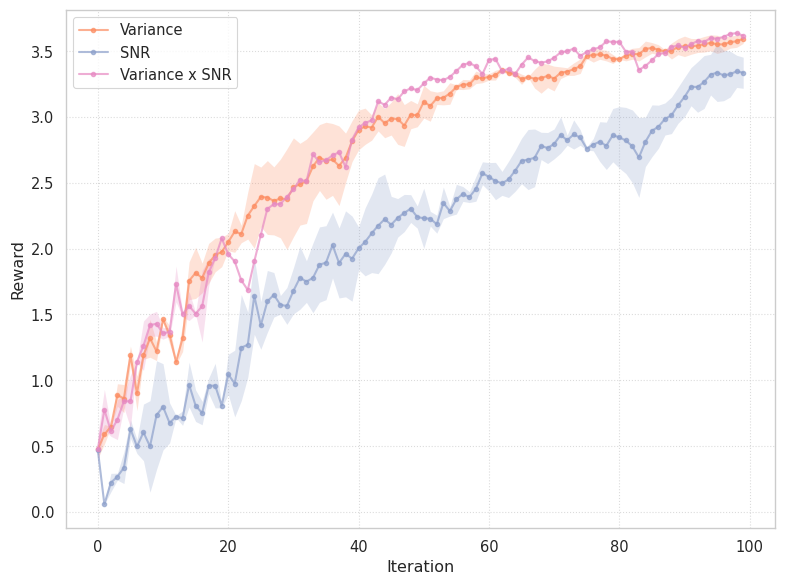

In [20]:
runs = {
    #"Full Trajectory": [run_paths['morning-wave-19'], run_paths['gentle-snowflake-112']],
   # "Uniform": [run_paths['atomic-smoke-24'], run_paths['lyric-wind-110']],
    #"Sensitivity": [run_paths['royal-plasma-100'], run_paths['clean-blaze-107']],
    "Variance": [run_paths['hopeful-cloud-103'], run_paths['tough-aardvark-108']],
    "SNR": [run_paths['sparkling-vortex-104'], run_paths['visionary-sunset-109']],
    #"Sensitivity x SNR": [run_paths['brisk-darkness-105'], run_paths['stilted-dew-113']],
    "Variance x SNR": [run_paths['expert-cherry-106'], run_paths['lucky-meadow-114']],
    }
metrics = {
    "train/reward": "Reward",
    # "train/ir_person": "ImageReward",
    # "train/aesthetics_score": "Aesthetic",
    #"train/sex_score_binary": "Gender"
    }
plot_wandb_metrics(runs, metrics)

# Sampled timestep distribution

In [9]:
def plot_overall_timestep_hist(run_path: str, show=True):
    """
    Given a W&B run path ("entity/project/run_id"),
    loads all timesteps/t=... metrics and plots a single aggregated histogram.

    Args:
        run_path (str): full run path, e.g. "amanda-mendes-cloudwalk/diffusion-finetune/abcd1234"
        show (bool): whether to display the matplotlib figure

    Returns:
        pd.Series: total counts per timestep
    """
    api = wandb.Api()
    run = api.run(run_path)

    # stream full history (efficiently)
    records = []
    for row in run.scan_history():  # no keys filter — wildcards not supported
        records.append(row)
    if not records:
        raise ValueError(f"No history found for run {run_path}")

    df = pd.DataFrame(records)

    # filter only the timestep columns
    ts_cols = [c for c in df.columns if c.startswith("timesteps/t=")]
    if not ts_cols:
        raise ValueError("No 'timesteps/t=' keys found in this run.")

    df_ts = df[ts_cols]

    # sum counts across all steps
    timestep_sums = df_ts.sum(axis=0)

    # parse timestep numbers and sort
    timesteps_and_counts = [
        (int(c.split("timesteps/t=")[1]), timestep_sums[c]) for c in timestep_sums.index
    ]
    timesteps_and_counts.sort(key=lambda pair: pair[0])

    timesteps = np.array([t for t, _ in timesteps_and_counts])
    counts = np.array([c for _, c in timesteps_and_counts])

    # prepare result
    series = pd.Series(counts, index=timesteps, name="count")

    # plot
    if show:
        fig, ax = plt.subplots(figsize=(12, 6))
        # Adjust width so bars are "fat" even if timesteps are spaced far apart
        # Compute minimum distance between adjacent timesteps, or fallback to 10 if only one
        if len(timesteps) > 1:
            min_step = np.min(np.diff(timesteps))
            bar_width = min_step * 0.8
        else:
            bar_width = 10  # fallback

        bars = ax.bar(timesteps, counts, width=bar_width, color="C0", align="center")
        ax.set_xlabel("Timestep")
        ax.set_ylabel("Total count across training")
        ax.set_title(f"Timestep sampling histogram — {run.name}")
        ax.set_xlim([timesteps.min() - bar_width, timesteps.max() + bar_width])
        ax.grid(axis='y', linestyle=':', alpha=0.4)

        # Set x-tick positions and labels for every bar, rotated 45 deg
        ax.set_xticks(timesteps)
        ax.set_xticklabels([str(t) for t in timesteps], rotation=45, ha='right')

        plt.tight_layout()
        plt.show()

    return series


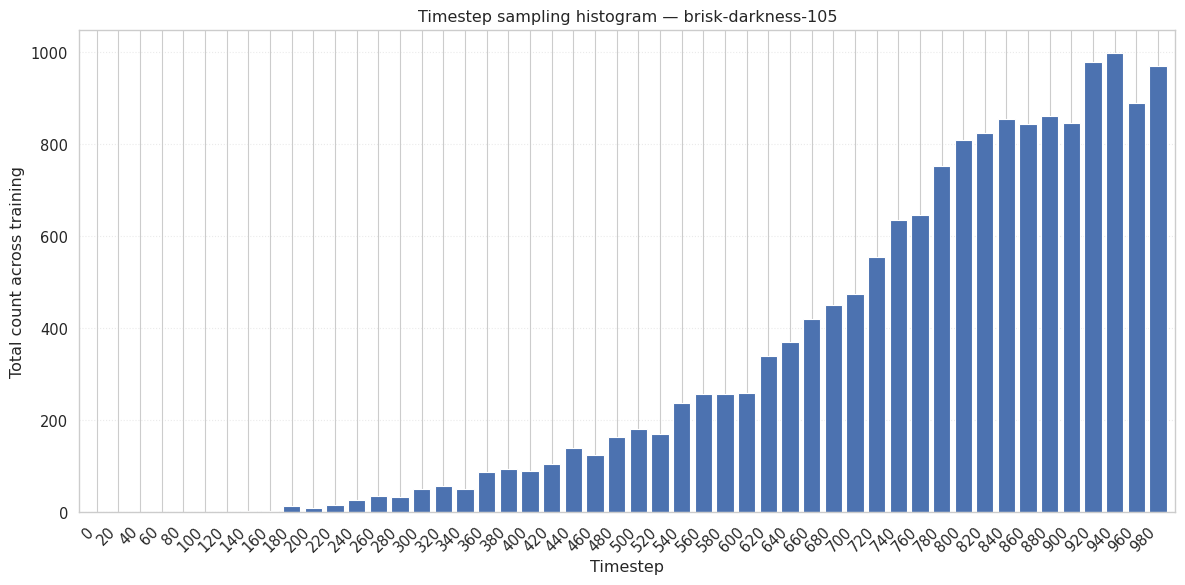

In [10]:
series = plot_overall_timestep_hist(run_paths['brisk-darkness-105'])

# Download sampling distribution

In [12]:
import wandb
run = wandb.init()
artifact = run.use_artifact('amanda-mendes-cloudwalk/diffusion-finetune/timestep-weights:v1', type='config')
artifact_dir = artifact.download()

wandb: Currently logged in as: amanda-mendes (amanda-mendes-cloudwalk) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


wandb:   1 of 1 files downloaded.  
